# RII — extract, clean, map to GPC, and assemble city emissions

One notebook for the 2026-07 release. It reads the four Tableau emissions exports (`sample/`), cleans them, validates the units, maps each RII unit to a GPC reference number, and applies the mapping to produce the GPC-ready city emissions and per-city totals. Review README: `../../README.md`. Need: `dataset-discovery/needs/2026-07-mn-city-ghgi`.

Flow: §1 load → §2 clean → §3 validate → §4 export emissions → §5 fit → §6 GPC mapping → §7 apply mapping → §8 findings.

**Units.** Every value is **tonnes CO₂e** — the exports are emissions views, not activity data. Confirmed by assertion in §3. Committed outputs (`data/`): `rii_emissions_long.csv` (cleaned source), `rii_to_gpc_mapping.csv` (unit → GPC), `rii_gpc_emissions.csv` (applied, city × GPC code). The per-city totals `rii_gpc_city_totals_2026-07.csv` are written to `sample/` (gitignored, regenerated by this notebook).

## 1. Load raw
Read each export with `header=None` — the real header is embedded in row 0 (parsing note: embedded header). Zero transformations here.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE = Path("sample")
DATA = Path("data"); DATA.mkdir(exist_ok=True)
RELEASE_YEAR = "2026-07"

raw = {
    "energy_residential":            pd.read_excel(SAMPLE / "total_energy_by_type_residential.xlsx", header=None),
    "energy_commercial_industrial":  pd.read_excel(SAMPLE / "total_energy_by_type_commercial.xlsx", header=None),
    "transport":                     pd.read_excel(SAMPLE / "vmt.xlsx", header=None),
    "waste":                         pd.read_excel(SAMPLE / "waste_by_type.xlsx", header=None),
}
{k: v.shape for k, v in raw.items()}

{'energy_residential': (30, 5),
 'energy_commercial_industrial': (30, 5),
 'transport': (120, 2),
 'waste': (72, 5)}

## 2. Clean
One block per README parsing note; blocks are self-contained so they port to Mage.

### 2a. Energy → long (parsing note: embedded row-0 header + redundant label column)
City is column 0; the fuel labels are in row 0; column 1 repeats the measure name and is dropped. Both sector files share this shape.

In [2]:
def clean_energy(df, sector):
    body = df.iloc[1:, [0, 2, 3, 4]].copy()
    body.columns = ["city", "Other", "Natural Gas", "Electricity"]
    long = body.melt(id_vars="city", var_name="subcategory", value_name="tco2e")
    long["indicator"] = "energy"; long["sector"] = sector
    return long

energy = pd.concat(
    [clean_energy(raw["energy_residential"], "residential"),
     clean_energy(raw["energy_commercial_industrial"], "commercial_industrial")],
    ignore_index=True)
energy["tco2e"] = pd.to_numeric(energy["tco2e"], errors="coerce")
energy["city"] = energy["city"].astype(str).str.strip()
energy.head()

,city,subcategory,tco2e,indicator,sector
0,Arden Hills,Other,177.235723,energy,residential
1,Blaine,Other,2284.523895,energy,residential
2,Circle Pines,Other,0.000000,energy,residential
3,Crookston,Other,1761.463530,energy,residential
4,Crystal,Other,206.454128,energy,residential


### 2b. Transport → long (parsing note: two-row header)
Rows 0–1 are `['','Year']` / `['','2024']`, cities start at row 2. Only this view carries a year label; the filename says `vmt` but the values are transport *emissions*.

In [3]:
transport = raw["transport"].iloc[2:, [0, 1]].copy()
transport.columns = ["city", "tco2e"]
transport["tco2e"] = pd.to_numeric(transport["tco2e"], errors="coerce")
transport["city"] = transport["city"].astype(str).str.strip()
transport["indicator"] = "transport"; transport["sector"] = "on_road"; transport["subcategory"] = "all_vehicles"
transport.head()

,city,tco2e,indicator,sector,subcategory
2,Albert Lea,41719.075484,transport,on_road,all_vehicles
3,Andover,80370.038738,transport,on_road,all_vehicles
4,Apple Valley,141200.795956,transport,on_road,all_vehicles
5,Arden Hills,157450.185964,transport,on_road,all_vehicles
6,Arlington,3140.562696,transport,on_road,all_vehicles


### 2c. Waste → long (parsing note: recycled placeholder)
Labels in row 0; column 1 redundant. `Recycled` is all-zero — a protocol placeholder (recycling carries no emissions), kept for transparency.

In [4]:
wbody = raw["waste"].iloc[1:, [0, 2, 3, 4]].copy()
wbody.columns = ["city", "Incinerated", "Landfilled", "Recycled"]
waste = wbody.melt(id_vars="city", var_name="subcategory", value_name="tco2e")
waste["tco2e"] = pd.to_numeric(waste["tco2e"], errors="coerce")
waste["city"] = waste["city"].astype(str).str.strip()
waste["indicator"] = "waste"; waste["sector"] = "msw"
waste.head()

,city,subcategory,tco2e,indicator,sector
0,Andover,Incinerated,690.339086,waste,msw
1,Apple Valley,Incinerated,912.894206,waste,msw
2,Arden Hills,Incinerated,2067.000268,waste,msw
3,Blaine,Incinerated,1608.157989,waste,msw
4,Bloomington,Incinerated,12537.514531,waste,msw


### 2d. Drop non-city rows and stack (parsing note: county mixed in)
Every file carries a `Ramsey County` row; remove non-city rows, then stack all indicators into one tidy long frame. All four exports are the 2024 data year (analyst-confirmed; only transport is labelled).

In [5]:
NON_CITY = {"Ramsey County"}
for d in (energy, waste): d["year"] = 2024
transport["year"] = 2024

cols = ["city", "indicator", "sector", "subcategory", "tco2e", "year"]
tidy = pd.concat([energy[cols], transport[cols], waste[cols]], ignore_index=True)
tidy = tidy[~tidy["city"].isin(NON_CITY)].reset_index(drop=True)
tidy["units"] = "tonnes_co2e"
tidy["src_unit_id"] = tidy["indicator"] + "/" + tidy["sector"] + "/" + tidy["subcategory"]
tidy.groupby("indicator")["city"].nunique()

indicator
energy        28
transport    117
waste         70
Name: city, dtype: int64

## 3. Validate
Assertions, not eyeballing. Coverage counts, the recycled-zero fact, and a **unit confirmation**: read as tCO₂e, values must give plausible per-capita transport and per-household electricity, else the tCO₂e labelling is wrong and we stop.

In [6]:
POP2020 = {"Minneapolis":429954,"Saint Paul":311527,"Rochester":121395,"Duluth":86697,"Mankato":44488,
    "Bloomington":89987,"Richfield":36994,"Hopkins":19079,"Saint Louis Park":50010,"Edina":53494,
    "Coon Rapids":63599,"Eagan":68855,"Eden Prairie":64198,"Minnetonka":53781,"Woodbury":75102}
HH2020 = {"Rochester":51680,"Minnetonka":23230,"Saint Louis Park":25141}  # occupied housing units, 2020

cov = tidy.groupby("indicator")["city"].nunique().to_dict()
assert cov["energy"] == 28 and cov["waste"] == 70 and cov["transport"] == 117, cov
rec = tidy[(tidy.indicator=="waste") & (tidy.subcategory=="Recycled")]["tco2e"]
assert (rec.fillna(0) == 0).all(), "Recycled emissions unexpectedly non-zero"
assert not set(tidy.city) & NON_CITY
tp = transport.set_index("city")["tco2e"]
percap = {c: tp[c]/POP2020[c] for c in POP2020 if c in tp.index}
assert all(1.0 <= v <= 8.0 for v in percap.values()), percap
res_elec = energy[(energy.sector=="residential") & (energy.subcategory=="Electricity")].set_index("city")["tco2e"]
kwh_per_hh = {c: (res_elec[c]/0.45)*1000/HH2020[c] for c in HH2020 if c in res_elec.index}
assert all(1500 <= v <= 20000 for v in kwh_per_hh.values()), kwh_per_hh
print("coverage:", cov)
print("transport tCO2e/capita:", {k: round(v,2) for k,v in percap.items()})

coverage: {'energy': 28, 'transport': 117, 'waste': 70}
transport tCO2e/capita: {'Minneapolis': np.float64(2.21), 'Saint Paul': np.float64(2.5), 'Rochester': np.float64(2.77), 'Duluth': np.float64(3.05), 'Mankato': np.float64(2.53), 'Bloomington': np.float64(4.88), 'Richfield': np.float64(4.9), 'Hopkins': np.float64(2.22), 'Saint Louis Park': np.float64(3.43), 'Edina': np.float64(4.17), 'Coon Rapids': np.float64(3.65), 'Eagan': np.float64(4.79), 'Eden Prairie': np.float64(3.94), 'Minnetonka': np.float64(5.22), 'Woodbury': np.float64(3.75)}


## 4. Export cleaned emissions
Tidy source table: city × indicator × sector × subcategory × tCO₂e.

In [7]:
emis_cols = ["city","indicator","sector","subcategory","tco2e","year","units","src_unit_id"]
out = DATA / "rii_emissions_long.csv"
tidy[emis_cols].to_csv(out, index=False)
print("wrote", out, "rows:", len(tidy), "| total tCO2e:", round(tidy.tco2e.sum()))
tidy[emis_cols].head()

wrote data/rii_emissions_long.csv rows: 495 | total tCO2e: 15710760


,city,indicator,sector,subcategory,tco2e,year,units,src_unit_id
0,Arden Hills,energy,residential,Other,177.235723,2024,tonnes_co2e,energy/residential/Other
1,Blaine,energy,residential,Other,2284.523895,2024,tonnes_co2e,energy/residential/Other
2,Circle Pines,energy,residential,Other,0.000000,2024,tonnes_co2e,energy/residential/Other
3,Crookston,energy,residential,Other,1761.463530,2024,tonnes_co2e,energy/residential/Other
4,Crystal,energy,residential,Other,206.454128,2024,tonnes_co2e,energy/residential/Other


## 5. Visualise & fit
Charts render inline. Fit cells answer only what the need raises: which cities are usable and how they compare for cohort selection.

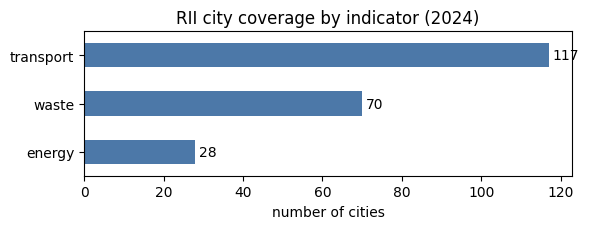

In [8]:
cov_s = tidy.groupby("indicator")["city"].nunique().sort_values()
ax = cov_s.plot.barh(color="#4C78A8", figsize=(6, 2.4))
ax.set_title("RII city coverage by indicator (2024)"); ax.set_xlabel("number of cities"); ax.set_ylabel("")
for i, v in enumerate(cov_s): ax.text(v + 1, i, str(v), va="center")
plt.tight_layout(); plt.show()

Cities with all three sectors: 28


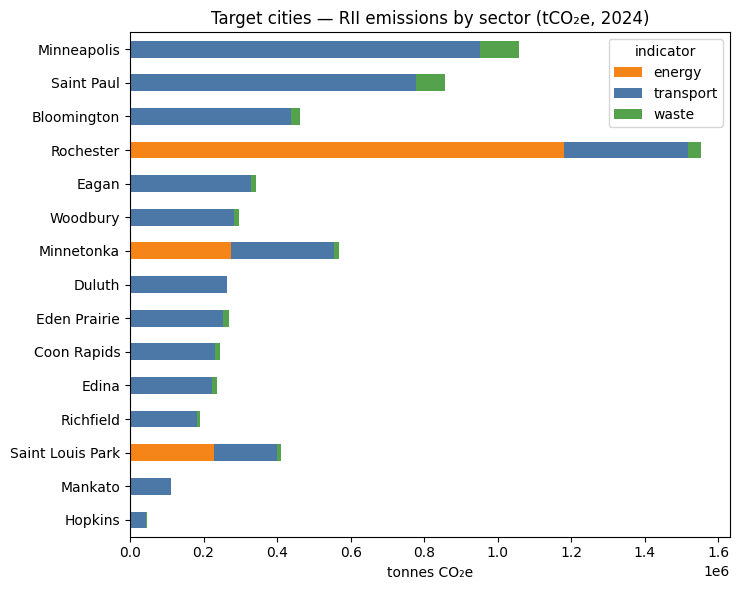

indicator,energy,transport,waste
city,,,
Minneapolis,NaN,950859.0,106385.0
Saint Paul,NaN,777373.0,78434.0
Rochester,1181407.0,336612.0,35864.0
Duluth,NaN,264329.0,NaN
Mankato,NaN,112384.0,NaN
Bloomington,NaN,438791.0,22482.0
Richfield,NaN,181421.0,9406.0
Hopkins,NaN,42421.0,4530.0
Saint Louis Park,228345.0,171594.0,12056.0


In [9]:
city_ind = tidy.groupby(["city","indicator"])["tco2e"].sum().unstack("indicator")
all_three = city_ind.dropna(subset=["energy","transport","waste"])
print(f"Cities with all three sectors: {len(all_three)}")
TARGETS = list(POP2020)
tv = city_ind.reindex(TARGETS)[["energy","transport","waste"]]
ax = tv.fillna(0).sort_values("transport").plot.barh(stacked=True, figsize=(7.5, 6),
        color={"energy":"#F58518","transport":"#4C78A8","waste":"#54A24B"})
ax.set_title("Target cities — RII emissions by sector (tCO₂e, 2024)"); ax.set_xlabel("tonnes CO₂e"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
tv.round(0)

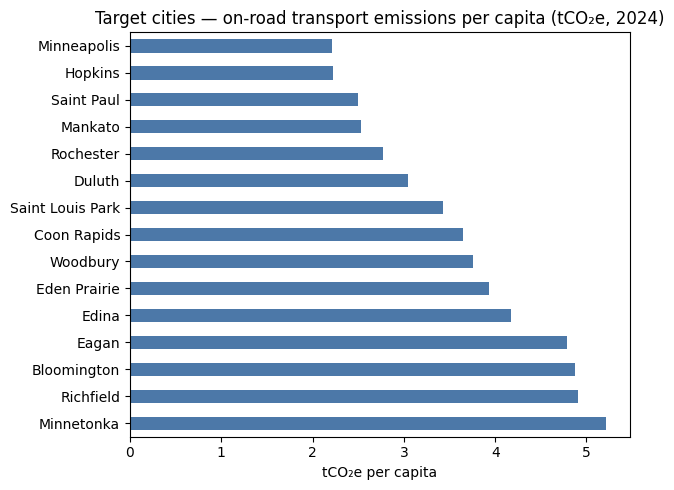

city
Minnetonka          5.22
Richfield           4.90
Bloomington         4.88
Eagan               4.79
Edina               4.17
Eden Prairie        3.94
Woodbury            3.75
Coon Rapids         3.65
Saint Louis Park    3.43
Duluth              3.05
Rochester           2.77
Mankato             2.53
Saint Paul          2.50
Hopkins             2.22
Minneapolis         2.21
dtype: float64

In [10]:
percap_t = (tv["transport"] / pd.Series(POP2020)).dropna().sort_values(ascending=False)
ax = percap_t.plot.barh(color="#4C78A8", figsize=(6.5, 5))
ax.set_title("Target cities — on-road transport emissions per capita (tCO₂e, 2024)")
ax.set_xlabel("tCO₂e per capita"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
percap_t.round(2)

## 6. Map RII units to GPC
One row per (RII unit, GPC target). GPC notation from `knowledge-base/topics/gpc-framework.md`. Link, don't attribute: where a unit spans two GPC sub-sectors it gets two rows and the value is never split. Confidence high | medium | none; agent drafts, human adjudicates mediums (§8).

In [11]:
MAP = [
    ("energy/residential/Electricity","I.1.2","Residential buildings",2,"high","RII residential electricity is Scope 2 grid-supplied energy consumed by homes -> I.1.2."),
    ("energy/residential/Natural Gas","I.1.1","Residential buildings",1,"high","RII residential fossil-gas is Scope 1 on-site stationary combustion -> I.1.1."),
    ("energy/residential/Other","I.1.1","Residential buildings",1,"medium","'Other' = non-utility residential heating fuels (fuel oil/propane/wood): Scope 1 -> I.1.1. Medium: RII energy may fold in purchased district heating (Scope 2, I.1.2); not separable."),
    ("energy/commercial_industrial/Electricity","I.2.2","Commercial & institutional buildings",2,"medium","Commercial/institutional share of RII's combined commercial+industrial+street-lighting electricity -> I.2.2. Medium: bucket spans I.2/I.3; value not split."),
    ("energy/commercial_industrial/Electricity","I.3.2","Manufacturing industries & construction",2,"medium","Industrial share of the same combined electricity bucket -> I.3.2. Medium: not separable; value not split."),
    ("energy/commercial_industrial/Natural Gas","I.2.1","Commercial & institutional buildings",1,"medium","Commercial/institutional share of combined stationary fossil-gas -> I.2.1. Medium: bucket spans I.2/I.3; value not split."),
    ("energy/commercial_industrial/Natural Gas","I.3.1","Manufacturing industries & construction",1,"medium","Industrial share of combined stationary fossil-gas -> I.3.1. Medium: not separable; value not split."),
    ("energy/commercial_industrial/Other","I.2.1","Commercial & institutional buildings",1,"medium","Commercial/institutional share of 'Other' non-utility fuels (Scope 1) -> I.2.1. Medium: combined bucket + possible district-energy; value not split."),
    ("energy/commercial_industrial/Other","I.3.1","Manufacturing industries & construction",1,"medium","Industrial share of 'Other' non-utility fuels (Scope 1) -> I.3.1. Medium: same ambiguity; value not split."),
    ("transport/on_road/all_vehicles","II.1.1","On-road transportation",1,"high","RII on-road uses the in-boundary (territorial) method = Scope 1 tailpipe within boundary -> II.1.1. EV electricity (II.1.2) negligible/folded."),
    ("waste/msw/Landfilled","III.1.1","Solid waste disposal",1,"medium","City MSW landfill emissions -> GPC III.1. Medium: RII uses methane-commitment (future emissions of this year's waste) vs GPC first-order-decay; values not GPC-conformant; in-city vs exported disposal not split."),
    ("waste/msw/Incinerated","III.3.1","Incineration & open burning",1,"medium","City MSW incineration/WTE -> GPC III.3. Medium: RII books WTE in the waste sector; GPC places WTE energy-recovery in Stationary Energy; placement differs."),
    ("waste/msw/Recycled","","",None,"none","Recycling carries zero emissions under the US Community Protocol (all-zero placeholder); no GPC source category applies."),
]
mapping = pd.DataFrame(MAP, columns=["src_unit_id","gpc_refno","gpc_sector_name","gpc_scope","mapping_confidence","rationale"])
mapping["gpc_sector"] = mapping["gpc_refno"].str.split(".").str[0]
mapping["gpc_subsector"] = mapping["gpc_refno"].str.rsplit(".", n=1).str[0]
mapping[["src_unit_id","gpc_refno","gpc_scope","mapping_confidence"]]

,src_unit_id,gpc_refno,gpc_scope,mapping_confidence
0,energy/residential/Electricity,I.1.2,2.0,high
1,energy/residential/Natural Gas,I.1.1,1.0,high
2,energy/residential/Other,I.1.1,1.0,medium
3,energy/commercial_industrial/Electricity,I.2.2,2.0,medium
4,energy/commercial_industrial/Electricity,I.3.2,2.0,medium
5,energy/commercial_industrial/Natural Gas,I.2.1,1.0,medium
6,energy/commercial_industrial/Natural Gas,I.3.1,1.0,medium
7,energy/commercial_industrial/Other,I.2.1,1.0,medium
8,energy/commercial_industrial/Other,I.3.1,1.0,medium
9,transport/on_road/all_vehicles,II.1.1,1.0,high


### 6a. Validate & export the mapping
Every source unit covered; every code a valid GPC BASIC/BASIC+ leaf; no duplicate pairs.

In [12]:
GPC_VALID = {"I.1.1","I.2.1","I.3.1","I.4.1","I.5.1","I.6.1","I.7.1","I.8.1","I.1.2","I.2.2","I.3.2","I.4.2","I.5.2","I.6.2",
    "II.1.1","II.2.1","II.3.1","II.4.1","II.5.1","II.1.2","II.2.2","II.3.2","II.4.2","II.5.2",
    "III.1.1","III.1.2","III.2.1","III.2.2","III.3.1","III.3.2","III.4.1","III.4.2",
    "I.1.3","I.2.3","I.3.3","I.4.3","I.5.3","I.6.3","II.1.3","II.2.3","II.3.3","II.4.3","IV.1","IV.2","V.1","V.2","V.3"}
units_present = set(tidy.src_unit_id.unique())
assert units_present == set(mapping.src_unit_id), units_present ^ set(mapping.src_unit_id)
bad = mapping.loc[(mapping.mapping_confidence!="none") & (~mapping.gpc_refno.isin(GPC_VALID)),"gpc_refno"].tolist()
assert not bad, bad
assert not mapping.duplicated(["src_unit_id","gpc_refno"]).any()
map_cols = ["src_unit_id","gpc_refno","gpc_sector","gpc_subsector","gpc_scope","gpc_sector_name","mapping_confidence","rationale"]
mapping[map_cols].to_csv(DATA / "rii_to_gpc_mapping.csv", index=False)
print("mapping:", mapping.mapping_confidence.value_counts().to_dict())

mapping: {'medium': 9, 'high': 3, 'none': 1}


### 6b. Coverage — both directions
Source units mapped vs none, and which GPC BASIC codes RII reaches vs leaves empty (its structural omissions).

In [13]:
BASIC = {"I.1.1","I.2.1","I.3.1","I.4.1","I.5.1","I.6.1","I.7.1","I.8.1","I.1.2","I.2.2","I.3.2","I.4.2","I.5.2","I.6.2",
    "II.1.1","II.2.1","II.3.1","II.4.1","II.5.1","II.1.2","II.2.2","II.3.2","II.4.2","II.5.2",
    "III.1.1","III.1.2","III.2.1","III.2.2","III.3.1","III.3.2","III.4.1","III.4.2"}
mapped = (mapping.mapping_confidence != "none").sum()
reached = sorted(set(mapping.gpc_refno) & BASIC)
unreached = sorted(BASIC - set(reached))
print(f"source units mapped: {mapping.src_unit_id[mapping.mapping_confidence!='none'].nunique()}/10  (1 none: recycling)")
print(f"GPC BASIC reached: {len(reached)}/{len(BASIC)} ->", reached)
print("UNREACHED (RII omits):", unreached)

source units mapped: 9/10  (1 none: recycling)
GPC BASIC reached: 9/32 -> ['I.1.1', 'I.1.2', 'I.2.1', 'I.2.2', 'I.3.1', 'I.3.2', 'II.1.1', 'III.1.1', 'III.3.1']
UNREACHED (RII omits): ['I.4.1', 'I.4.2', 'I.5.1', 'I.5.2', 'I.6.1', 'I.6.2', 'I.7.1', 'I.8.1', 'II.1.2', 'II.2.1', 'II.2.2', 'II.3.1', 'II.3.2', 'II.4.1', 'II.4.2', 'II.5.1', 'II.5.2', 'III.1.2', 'III.2.1', 'III.2.2', 'III.3.2', 'III.4.1', 'III.4.2']


## 7. Apply the mapping to city emissions
Collapse each unit's mapping to a single applied GPC code (a combined `I.2+I.3` where it spans two) so the value is carried once, then join. Validated to preserve the total exactly — no double counting.

In [14]:
def combine(g):
    codes = sorted(g.gpc_refno.astype(str)[g.gpc_refno.astype(str) != ""])
    return pd.Series({
        "gpc_code_applied": "+".join(codes) or None,
        "gpc_sector": (g.gpc_sector.dropna().unique().tolist() or [None])[0],
        "gpc_scope": (g.gpc_scope.dropna().unique().tolist() or [None])[0],
        "mapping_confidence": "none" if (g.mapping_confidence=="none").all()
                              else ("high" if "high" in set(g.mapping_confidence) else "medium"),
    })
applied = mapping.groupby("src_unit_id", as_index=False).apply(combine, include_groups=False)

gpc_emis = (tidy.merge(applied, on="src_unit_id", how="left")
            .loc[lambda d: d.mapping_confidence != "none",
                 ["city","indicator","sector","subcategory","gpc_sector","gpc_code_applied","gpc_scope","tco2e","mapping_confidence","year"]]
            .reset_index(drop=True))
before = tidy.loc[tidy.src_unit_id != "waste/msw/Recycled", "tco2e"].sum()
assert abs(before - gpc_emis.tco2e.sum()) < 1e-6, (before, gpc_emis.tco2e.sum())
gpc_emis.to_csv(DATA / "rii_gpc_emissions.csv", index=False)
print(f"GPC-ready emissions: {len(gpc_emis)} rows, total {round(gpc_emis.tco2e.sum()):,} tCO2e preserved")
gpc_emis.head(9)

GPC-ready emissions: 425 rows, total 15,710,760 tCO2e preserved


,city,indicator,sector,subcategory,gpc_sector,gpc_code_applied,gpc_scope,tco2e,mapping_confidence,year
0,Arden Hills,energy,residential,Other,I,I.1.1,1.0,177.235723,medium,2024
1,Blaine,energy,residential,Other,I,I.1.1,1.0,2284.523895,medium,2024
2,Circle Pines,energy,residential,Other,I,I.1.1,1.0,0.000000,medium,2024
3,Crookston,energy,residential,Other,I,I.1.1,1.0,1761.463530,medium,2024
4,Crystal,energy,residential,Other,I,I.1.1,1.0,206.454128,medium,2024
5,Gem Lake,energy,residential,Other,I,I.1.1,1.0,48.512023,medium,2024
6,Golden Valley,energy,residential,Other,I,I.1.1,1.0,518.797391,medium,2024
7,Lauderdale,energy,residential,Other,I,I.1.1,1.0,74.849159,medium,2024
8,Little Canada,energy,residential,Other,I,I.1.1,1.0,507.141744,medium,2024


### 7a. Final result — per-city GPC sector totals & BASIC-partial
Aggregating at the GPC **sector** level (I/II/III) is safe even where the sub-sector is ambiguous. `basic_partial_tco2e` sums only the sectors a city has; `complete_basic3` flags the cities with all three. A transport-only city's total is transport only — never a full inventory.

In [15]:
SECTOR_NAME = {"I":"I_stationary_energy","II":"II_transportation","III":"III_waste"}
wide = gpc_emis.groupby(["city","gpc_sector"])["tco2e"].sum().unstack("gpc_sector").rename(columns=SECTOR_NAME)
for c in SECTOR_NAME.values():
    if c not in wide: wide[c] = pd.NA
wide = wide[list(SECTOR_NAME.values())]

def sectors_present(r):
    labs = []
    if pd.notna(r["I_stationary_energy"]): labs.append("energy")
    if pd.notna(r["II_transportation"]): labs.append("transport")
    if pd.notna(r["III_waste"]): labs.append("waste")
    return "+".join(labs)
wide["sectors_present"] = wide.apply(sectors_present, axis=1)
wide["n_sectors"] = wide[list(SECTOR_NAME.values())].notna().sum(axis=1)
wide["basic_partial_tco2e"] = wide[list(SECTOR_NAME.values())].sum(axis=1, min_count=1)
wide["complete_basic3"] = wide["n_sectors"] == 3
city_totals = wide.reset_index().sort_values("basic_partial_tco2e", ascending=False)
city_totals.to_csv(SAMPLE / f"rii_gpc_city_totals_{RELEASE_YEAR}.csv", index=False)
print("city totals:", len(city_totals), "| complete 3-sector:", int(city_totals.complete_basic3.sum()))
city_totals.head(15)

city totals: 117 | complete 3-sector: 28


gpc_sector,city,I_stationary_energy,II_transportation,III_waste,sectors_present,n_sectors,basic_partial_tco2e,complete_basic3
84,Rochester,1.181407e+06,336612.050363,35864.123761,energy+transport+waste,3,1.553883e+06,True
60,Minneapolis,NaN,950858.645237,106385.162100,transport+waste,2,1.057244e+06,False
92,Saint Paul,NaN,777372.693421,78434.207591,transport+waste,2,8.558069e+05,False
9,Blaine,4.003572e+05,258651.355756,16197.092190,energy+transport+waste,3,6.752056e+05,True
61,Minnetonka,2.734884e+05,280504.622338,13727.827334,energy+transport+waste,3,5.677209e+05,True
10,Bloomington,NaN,438790.740166,22481.694366,transport+waste,2,4.612724e+05,False
91,Saint Louis Park,2.283451e+05,171593.787357,12055.663472,energy+transport+waste,3,4.119946e+05,True
57,Maplewood,1.912110e+05,169305.839372,10518.881348,energy+transport+waste,3,3.710357e+05,True
87,Roseville,1.868272e+05,170934.919088,9086.729658,energy+transport+waste,3,3.668489e+05,True
23,Eagan,NaN,329603.330701,13420.925666,transport+waste,2,3.430243e+05,False


In [16]:
# Final target-city result
target_result = (city_totals.set_index("city").reindex(TARGETS)
                 [["I_stationary_energy","II_transportation","III_waste","basic_partial_tco2e","sectors_present","complete_basic3"]])
target_result.round(0)

gpc_sector,I_stationary_energy,II_transportation,III_waste,basic_partial_tco2e,sectors_present,complete_basic3
city,,,,,,
Minneapolis,NaN,950859.0,106385.0,1057244.0,transport+waste,False
Saint Paul,NaN,777373.0,78434.0,855807.0,transport+waste,False
Rochester,1181407.0,336612.0,35864.0,1553883.0,energy+transport+waste,True
Duluth,NaN,264329.0,NaN,264329.0,transport,False
Mankato,NaN,112384.0,NaN,112384.0,transport,False
Bloomington,NaN,438791.0,22482.0,461272.0,transport+waste,False
Richfield,NaN,181421.0,9406.0,190827.0,transport+waste,False
Hopkins,NaN,42421.0,4530.0,46951.0,transport+waste,False
Saint Louis Park,228345.0,171594.0,12056.0,411995.0,energy+transport+waste,True


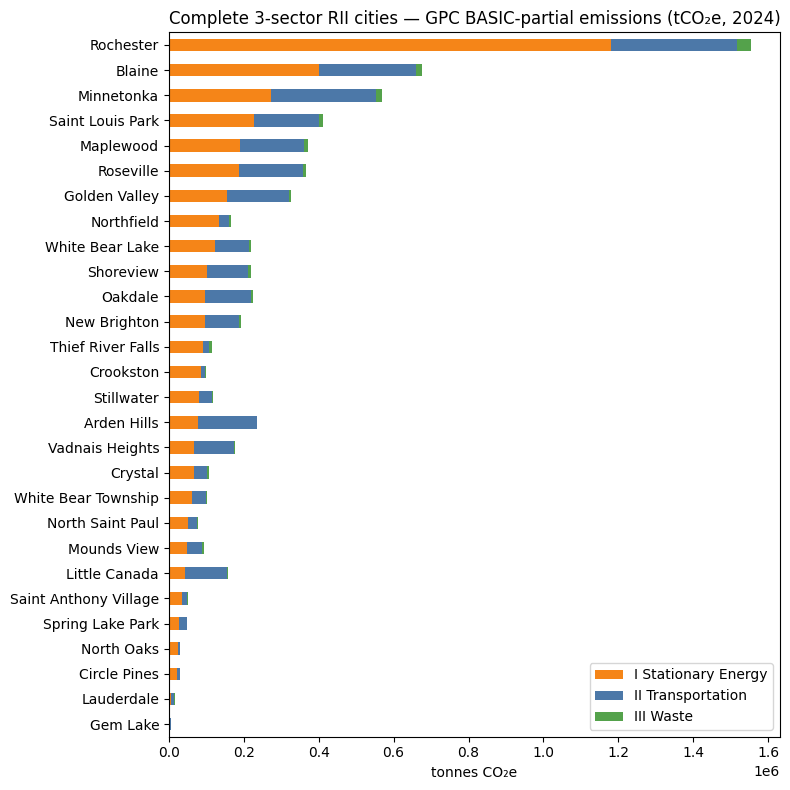

In [17]:
# GPC composition for the 28 complete-3 cities
comp = (city_totals[city_totals.complete_basic3].set_index("city")
        [["I_stationary_energy","II_transportation","III_waste"]].sort_values("I_stationary_energy"))
ax = comp.plot.barh(stacked=True, figsize=(8, 8),
        color={"I_stationary_energy":"#F58518","II_transportation":"#4C78A8","III_waste":"#54A24B"})
ax.set_title("Complete 3-sector RII cities — GPC BASIC-partial emissions (tCO₂e, 2024)")
ax.set_xlabel("tonnes CO₂e"); ax.set_ylabel("")
ax.legend(["I Stationary Energy","II Transportation","III Waste"], loc="lower right")
plt.tight_layout(); plt.show()

## 8. Findings

**Units confirmed as tonnes CO₂e.** All four exports are emissions views, not activity data. Three checks agree (§3): waste `Recycled` is zero for every city (zero-emissions by protocol; tonnage never would be), residential electricity read as tCO₂e implies a sane per-household kWh, and transport reads at 2–4 tCO₂e/capita.

**Coverage is per-indicator, not per-city.** After dropping the shared `Ramsey County` row: transport 117 cities (all 15 targets), waste 70 (no Duluth/Mankato), energy 28 (a filtered NE-metro subset; only Rochester, Minnetonka, Saint Louis Park among the targets). All 28 energy cities also carry transport and waste, so the complete-3 set is exactly those 28.

**GPC mapping (agent-drafted; human to adjudicate the mediums).** Ten units, nine mapped, one none. High: residential electricity → I.1.2, residential gas → I.1.1, transport → II.1.1. The mediums cluster into three decisions — (1) RII's combined commercial/industrial bucket dual-maps to I.2 and I.3 without splitting the value; (2) 'Other' fuels treated as Scope 1 combustion despite possible district-energy contamination; (3) waste maps to the right GPC sectors (III.1, III.3) but on a non-conformant accounting basis. RII reaches 9 of 32 GPC BASIC codes; it omits wastewater (III.4), composting (III.2), rail/aviation/off-road (II.2/4/5), and energy-industry own use (I.4).

**Applied output.** The join preserves each city's total exactly (the commercial/industrial value carried once under a combined `I.2+I.3` code). `basic_partial_tco2e` must be read with `complete_basic3`: only 28 cities carry a genuine three-sector inventory, and even those are not a certified GPC BASIC total (omissions above; waste on methane-commitment basis).

**Adjudication:** medium/none mapping rows drafted by agent 2026-07-05; human adjudicator + date to be recorded here.